<a href="https://colab.research.google.com/github/YoshnaM/6CS012-Artificial-Intelligence-and-Machine-Learning/blob/main/2406791_Yoshna_Maharjan_Code_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (Sentiment Analysis) Text Classification with RNN

### Environment Setup

In [1]:
!pip install -q numpy==1.26.4
!pip install -q scipy==1.11.4
!pip install -q gensim==4.3.3
!pip install -q gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 59.8 MB/s eta 0:00:00


### Import Libraries

In [51]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# NLP Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

# Evaluation Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Eord Embeddings
import gensim
import gensim.downloader as api

# GUI
import gradio as gr

# Text Preprocessing, Tokenization, and Sequence Padding

### Load the Dataset

In [52]:
file_path = '/content/drive/MyDrive/Artificial_Intelligence_And_Machine_Learning/spamvsham.csv'
df = pd.read_csv(file_path, encoding='latin-1')

# Keep only required columns
df = df[['v1', 'v2']].copy()

# Rename columns for clarity
df.columns = ['label', 'message']

# Display dataset shape
print(f"Dataset Shape: {df.shape}")

# Show first 5 rows
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [53]:
# Class distribution
print("Class Distribution:")
df['label'].value_counts()

Class Distribution:


,count
label,
ham,4825
spam,747


In [54]:
df['length'] = df['message'].apply(len)
print('\nMessage Length Statistics:')
df['length'].describe()


Message Length Statistics:


,length
count,5572.000000
mean,80.118808
std,59.690841
min,2.000000
25%,36.000000
50%,61.000000
75%,121.000000
max,910.000000



Label encoding applied: ham=0, spam=1


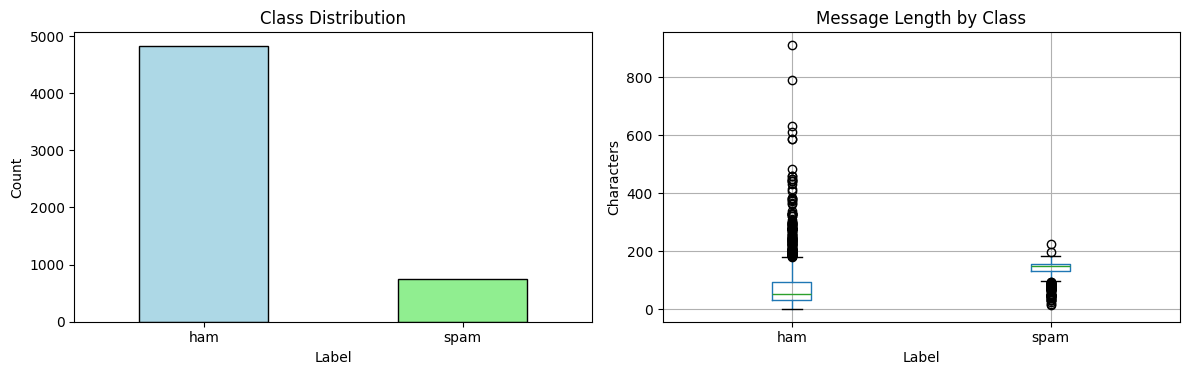

In [55]:
# Encode labels: ham = 0, spam = 1
df['label_enc'] = df['label'].map({'spam': 1, 'ham': 0})
print("\nLabel encoding applied: ham=0, spam=1")

# Create message length column
df['length'] = df['message'].apply(len)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['label'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['lightblue', 'lightgreen'],
    edgecolor='black'
)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Boxplot
df.boxplot(column='length', by='label', ax=axes[1])

axes[1].set_title('Message Length by Class')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Characters')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Clean the Text

In [56]:
CONTRACTIONS = {
    "don't": "do not",   "doesn't": "does not",  "didn't": "did not",
    "won't":  "will not", "can't":   "cannot",     "couldn't": "could not",
    "shouldn't": "should not", "wouldn't": "would not", "isn't": "is not",
    "aren't":    "are not",    "wasn't":   "was not",   "weren't": "were not",
    "haven't":   "have not",   "hasn't":   "has not",   "hadn't": "had not",
    "i'm":  "i am",   "i've":   "i have",  "i'll":  "i will",  "i'd":  "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is",   "she's": "she is",   "it's": "it is",
    "we're": "we are", "we've":  "we have",  "we'll": "we will",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "that's": "that is", "there's": "there is", "what's": "what is",
    "let's":  "let us",  "here's":  "here is",  "who's":  "who is"
}

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def expand_contractions(text: str) -> str:
    """
    Expand common English contractions into full forms.

    Args:
        text (str): Input sentence.

    Returns:
        str: Text with contractions expanded.
    """
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text: str) -> str:
    """
    Full preprocessing pipeline.

    Steps:
    1. Lowercasing
    2. Expanding contractions
    3. Removing URLs, mentions, hashtags
    4. Removing numbers and punctuations
    5. Tokenization
    6. Stopword removal
    7. Lemmatization

    Args:
        text (str): Raw input message.

    Returns:
        str: Cleaned text ready for tokenization.
    """

    # Convert text to lowercase
    text = text.lower()

    # Expand contractions
    text = expand_contractions(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove punctuations and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Stopword removal and lemmatization
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 1
    ]

    return ' '.join(tokens)

In [57]:
df['cleaned_message'] = df['message'].apply(clean_text)

print("Sample raw vs cleaned:")
for i in [0, 2, 4]:
    print(f"\n  [{i}] Original : {df['message'].iloc[i]}")
    print(f"       Cleaned  : {df['cleaned_message'].iloc[i]}")

Sample raw vs cleaned:

  [0] Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
       Cleaned  : go jurong point crazy available bugis great world la buffet cine got amore wat

  [2] Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
       Cleaned  : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over

  [4] Original : Nah I don't think he goes to usf, he lives around here though
       Cleaned  : nah think go usf life around though


### Visualize the Cleaned Data

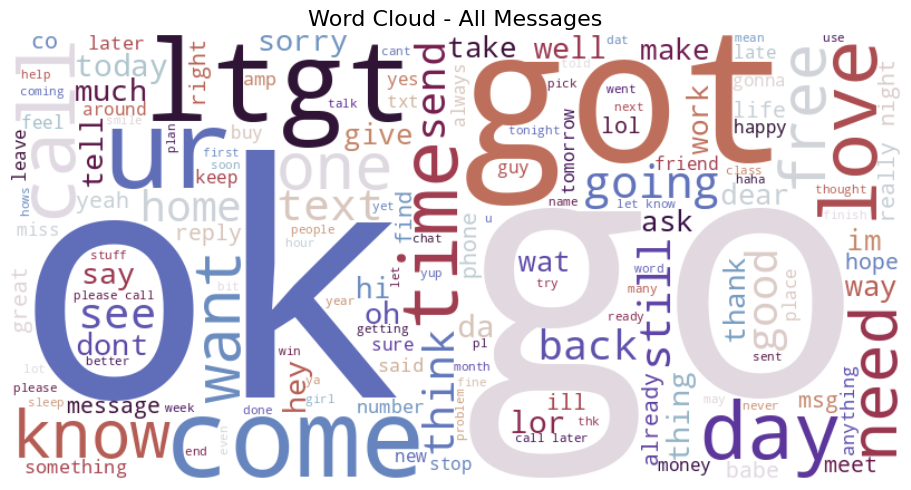

In [58]:
all_text = ' '.join(df['cleaned_message'].values)
wc_all = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='twilight',
    max_words=150
).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - All Messages', fontsize=16)
plt.tight_layout()
plt.show()

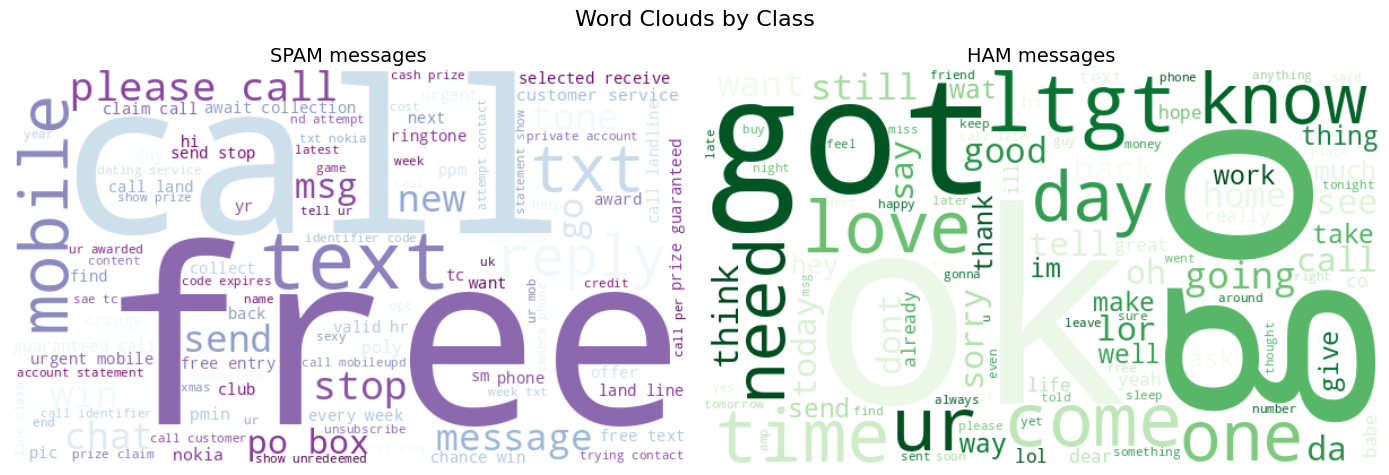

In [59]:
spam_text = ' '.join(df[df['label'] == 'spam']['cleaned_message'].values)
ham_text  = ' '.join(df[df['label'] == 'ham']['cleaned_message'].values)

wc_spam = WordCloud(
    width=600,
    height=350,
    background_color='white',
    colormap='BuPu',
    max_words=100
).generate(spam_text)

wc_ham  = WordCloud(
    width=600,
    height=350,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(ham_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wc_spam, interpolation='bilinear'); axes[0].axis('off'); axes[0].set_title('SPAM messages', fontsize=14)
axes[1].imshow(wc_ham,  interpolation='bilinear'); axes[1].axis('off'); axes[1].set_title('HAM messages',  fontsize=14)
plt.suptitle('Word Clouds by Class', fontsize=16)
plt.tight_layout()
plt.show()

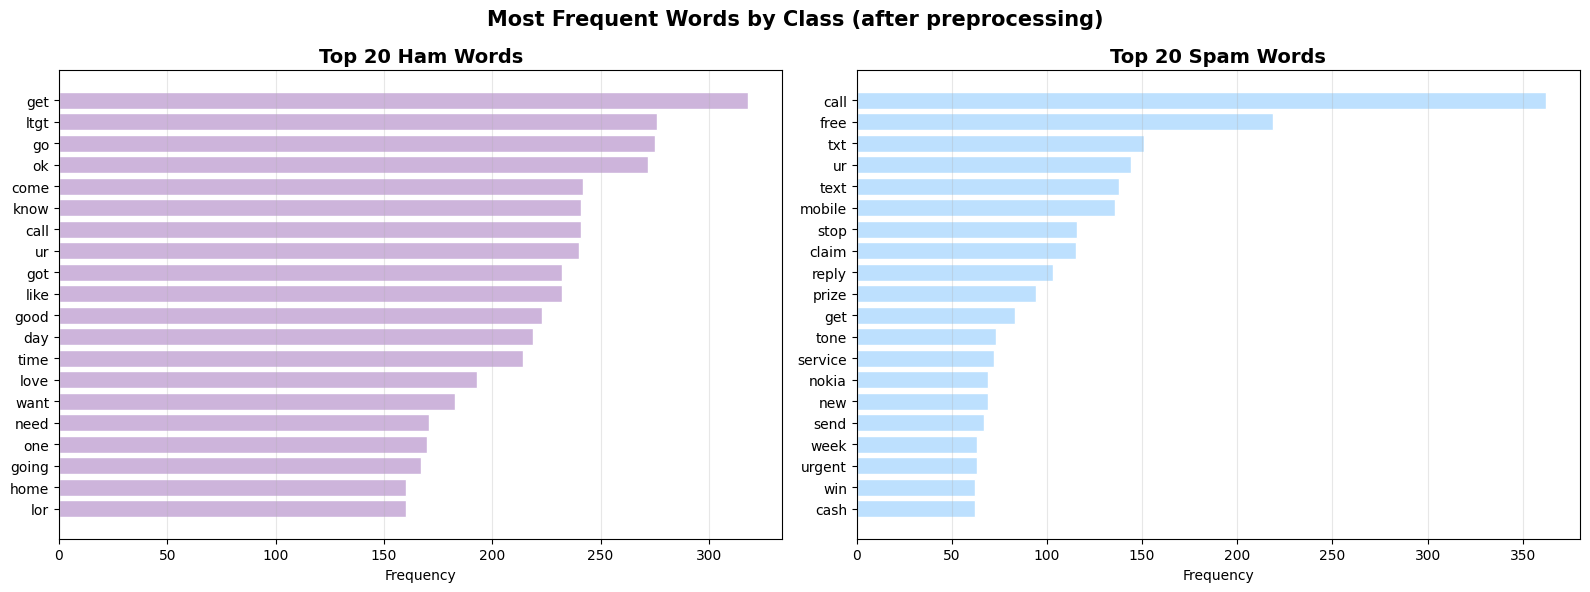

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, color in zip(
    axes,
    ['ham', 'spam'],
    ['Top 20 Ham Words', 'Top 20 Spam Words'],
    ['#CDB4DB', '#BDE0FE']
):
    words_list = ' '.join(df[df['label'] == label]['cleaned_message']).split()
    top_words  = Counter(words_list).most_common(20)
    words, counts = zip(*top_words)
    ax.barh(
        words[::-1],
        counts[::-1],
        color=color,
        edgecolor='white'
    )
    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Most Frequent Words by Class (after preprocessing)',
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

### Tokenization and Padding

In [61]:
X = df['cleaned_message'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train)}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing  samples : {len(X_test)}   ({len(X_test)/len(X)*100:.1f}%)")

Training samples : 4457  (80.0%)
Testing  samples : 1115   (20.0%)


In [62]:
VOCAB_SIZE = 10000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print(f"Fitted Vocabulary : {len(tokenizer.word_index):,} unique tokens")
print(f"Sample Text       : {X_train[0]}")
print(f'Sample Sequence   : {X_train_seq[0]}')

Fitted Vocabulary : 6,909 unique tokens
Sample Text       : going nothing greatbye
Sample Sequence   : [21, 216, 3109]


In [63]:
lengths = [len(s) for s in X_train_seq]

p50  = int(np.percentile(lengths, 50))
p90  = int(np.percentile(lengths, 90))
p95  = int(np.percentile(lengths, 95))
pmax = int(np.percentile(lengths, 100))

print("Sequence length percentiles (training set):")
print(f"  50th : {p50}")
print(f"  90th : {p90}")
print(f"  95th : {p95}   ← selected as MAX_LEN")
print(f"  Max  : {pmax}")

MAX_LEN = p95

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f"\nPadded training shape : {X_train_pad.shape}")
print(f"Padded testing  shape : {X_test_pad.shape}")

Sequence length percentiles (training set):
  50th : 7
  90th : 16
  95th : 18   ← selected as MAX_LEN
  Max  : 79

Padded training shape : (4457, 18)
Padded testing  shape : (1115, 18)


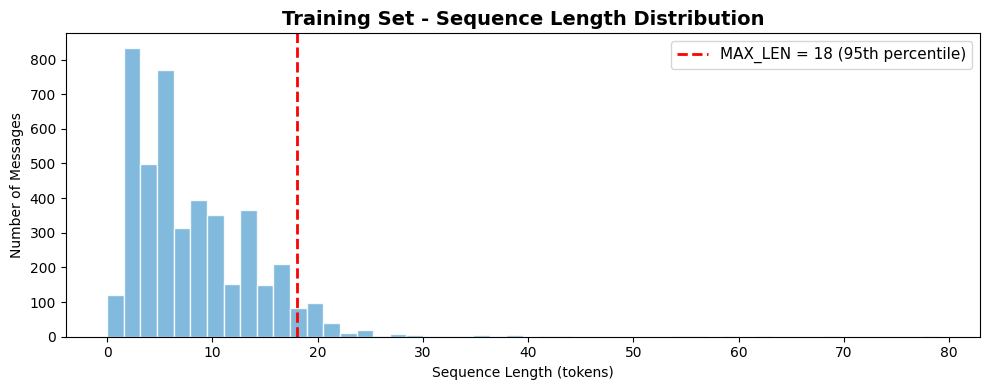

In [64]:
plt.figure(figsize=(10, 4))
plt.hist(
    lengths,
    bins=50,
    color='#6baed6',
    edgecolor='white',
    alpha=0.85
)
plt.axvline(
    MAX_LEN,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'MAX_LEN = {MAX_LEN} (95th percentile)'
)
plt.title(
    'Training Set - Sequence Length Distribution',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Number of Messages')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Model Building and Training

### Shared Hyperparameters

In [65]:
EMBED_DIM    = 64
RNN_UNITS    = 64
DROPOUT_RATE = 0.3
EPOCHS       = 20
BATCH_SIZE   = 64

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

### Model 1: Simple RNN with a trainable Embedded Layer

In [66]:
tf.random.set_seed(42)

rnn_model = Sequential(name='SimpleRNN_Model')
rnn_model.add(Input(shape=(MAX_LEN,)))

rnn_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
))
rnn_model.add(SimpleRNN(RNN_UNITS, return_sequences=False))
rnn_model.add(Dropout(DROPOUT_RATE))
rnn_model.add(Dense(32, activation='relu'))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2: LSTM with a trainable Embedded Layer

In [67]:
tf.random.set_seed(42)

lstm_model = Sequential(name='LSTM_Trainable_Embedding')
lstm_model.add(Input(shape=(MAX_LEN,)))

lstm_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
))
lstm_model.add(LSTM(RNN_UNITS, return_sequences=False))
lstm_model.add(Dropout(DROPOUT_RATE))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3: LSTM with pretrained Word2Vec Embeddings

In [68]:
print("Downloading pretrained GloVe embeddings (glove-wiki-gigaword-50)")

# Load Pre-trained GloVe Embeddings
embedding_model = api.load('glove-wiki-gigaword-50')    # 50-dimensional GloVe

embedding_dim = 50

print(f"\nGloVe model loaded!")
print(f"Vocabulary size     : {len(embedding_model):,}")
print(f"Embedding dimension : {embedding_dim}")


GloVe model loaded!
Vocabulary size     : 400,000
Embedding dimension : 50


In [69]:
word_index       = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))

found, not_found = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100

print(f"Embedding matrix shape      : {embedding_matrix.shape}")
print(f"Words covered by GloVe      : {found:,}  ({coverage:.1f}%)")
print(f"Words NOT in GloVe (zeros)  : {not_found:,}  ({100-coverage:.1f}%)")

Embedding matrix shape      : (10000, 50)
Words covered by GloVe      : 5,063  (73.3%)
Words NOT in GloVe (zeros)  : 1,846  (26.7%)


In [70]:
tf.random.set_seed(42)

lstm_w2v_model = Sequential(name='LSTM_GloVe_Embedding')
lstm_w2v_model.add(Input(shape=(MAX_LEN,)))

lstm_w2v_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
))
lstm_w2v_model.add(LSTM(RNN_UNITS, return_sequences=False))
lstm_w2v_model.add(Dropout(DROPOUT_RATE))
lstm_w2v_model.add(Dense(32, activation='relu'))
lstm_w2v_model.add(Dense(1,  activation='sigmoid'))

lstm_w2v_model.summary()

Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 18, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

# Model Training and Evaluation

In [71]:
def compile_and_train(model, X_tr, y_tr, X_val, y_val):
    """
    Compiles and trains a deep learning model for binary classification.

    Args:
        model (tf.keras.Model): Keras model to train.
        X_tr (array): Training features.
        y_tr (array): Training labels.
        X_val (array): Validation features.
        y_val (array): Validation labels.

    Returns:
        History: Training history object containing loss/accuracy metrics.
    """

    # Compile model
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    # Train model
    history = model.fit(
        X_tr, y_tr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )
    return history

print('Models compiled. Ready to train.')

Models compiled. Ready to train.


In [72]:
print('Training Model 1 - Simple RNN\n')
history_rnn = compile_and_train(
    rnn_model,
    X_train_pad,
    y_train,
    X_test_pad,
    y_test
)

Training Model 1 - Simple RNN

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9287 - loss: 0.2071 - val_accuracy: 0.9758 - val_loss: 0.0967
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9863 - loss: 0.0592 - val_accuracy: 0.9767 - val_loss: 0.0795
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9939 - loss: 0.0284 - val_accuracy: 0.9740 - val_loss: 0.0866
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9969 - loss: 0.0152 - val_accuracy: 0.9803 - val_loss: 0.0823
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9987 - loss: 0.0103 - val_accuracy: 0.9749 - val_loss: 0.1170
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [73]:
print('Training Model 2 - LSTM (Trainable Embedding)\n')
history_lstm = compile_and_train(
    lstm_model,
    X_train_pad,
    y_train,
    X_test_pad,
    y_test
)

Training Model 2 - LSTM (Trainable Embedding)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8945 - loss: 0.2954 - val_accuracy: 0.9686 - val_loss: 0.1153
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9841 - loss: 0.0596 - val_accuracy: 0.9848 - val_loss: 0.0568
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9960 - loss: 0.0201 - val_accuracy: 0.9812 - val_loss: 0.0794
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9960 - loss: 0.0176 - val_accuracy: 0.9776 - val_loss: 0.0955
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9987 - loss: 0.0086 - val_accuracy: 0.9686 - val_loss: 0.1062
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [74]:
print('Training Model 3 - LSTM (GloVe Embedding)\n')
history_lstm_w2v = compile_and_train(
    lstm_w2v_model,
    X_train_pad,
    y_train,
    X_test_pad,
    y_test
)

Training Model 3 - LSTM (GloVe Embedding)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9098 - loss: 0.3048 - val_accuracy: 0.9534 - val_loss: 0.1499
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9585 - loss: 0.1253 - val_accuracy: 0.9641 - val_loss: 0.1124
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9643 - loss: 0.1054 - val_accuracy: 0.9641 - val_loss: 0.1029
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


### Training vs Valisation - Loss and Accuracy Plots

In [75]:
def plot_history(history, title, ax_loss, ax_acc):
    """
    Plot training vs validation loss and accuracy.
    """
    epochs_ran = range(1, len(history.history['loss']) + 1)

    # Loss subplot
    ax_loss.plot(
        epochs_ran,
        history.history['loss'],
        label='Train Loss',
        marker='o',
        markersize=4
    )
    ax_loss.plot(
        epochs_ran,
        history.history['val_loss'],
        label='Val Loss',
        marker='s',
        markersize=4,
        linestyle='--'
    )
    ax_loss.set_title(
        f'{title} - Loss',
        fontweight='bold'
    )
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    # Accuracy subplot
    ax_acc.plot(
        epochs_ran,
        history.history['accuracy'],
        label='Train Acc',
        marker='o',
        markersize=4
    )
    ax_acc.plot(
        epochs_ran,
        history.history['val_accuracy'],
        label='Val Acc',
        marker='s',
        markersize=4,
        linestyle='--'
    )
    ax_acc.set_title(
        f'{title} - Accuracy',
        fontweight='bold'
    )
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

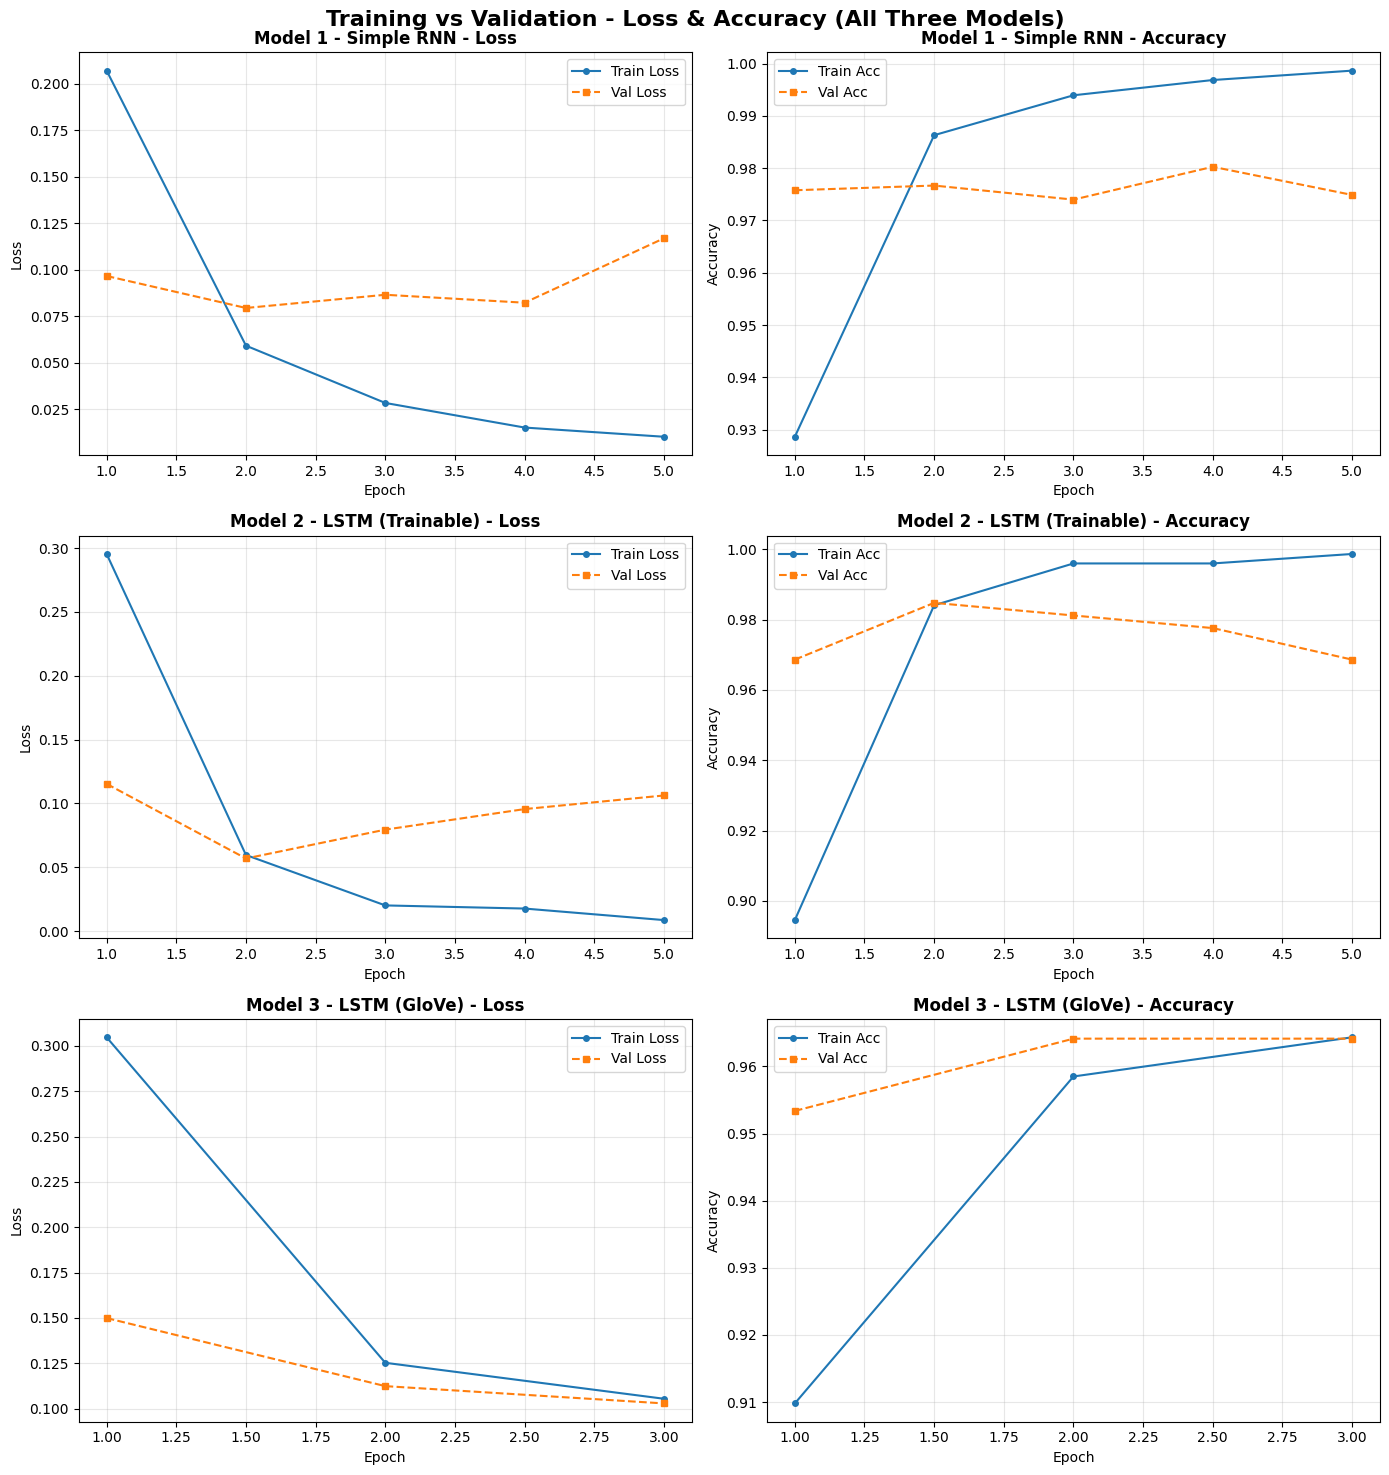

In [76]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle(
    'Training vs Validation - Loss & Accuracy (All Three Models)',
    fontsize=16,
    fontweight='bold'
)

plot_history(
    history_rnn,
    'Model 1 - Simple RNN',
    axes[0][0],
    axes[0][1]
)
plot_history(
    history_lstm,
    'Model 2 - LSTM (Trainable)',
    axes[1][0],
    axes[1][1]
)
plot_history(
    history_lstm_w2v,
    'Model 3 - LSTM (GloVe)',
    axes[2][0],
    axes[2][1]
)

plt.tight_layout()
plt.show()

### Comparative Performance Bar Chart

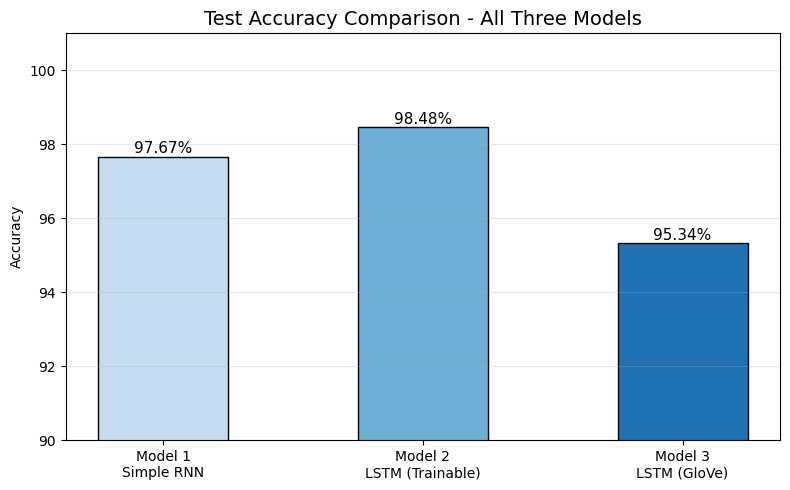

In [77]:
models_info = {
    'Model 1\nSimple RNN': rnn_model,
    'Model 2\nLSTM (Trainable)': lstm_model,
    'Model 3\nLSTM (GloVe)': lstm_w2v_model,
}

test_accuracies = {}
for name, model in models_info.items():
    _, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    test_accuracies[name] = acc * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(
    test_accuracies.keys(),
    test_accuracies.values(),
    color=['#c6dbef', '#6baed6', '#2171b5'],
    edgecolor='black',
    width=0.5
)
for bar, val in zip(bars, test_accuracies.values()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{val:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )
plt.ylim(90, 101)
plt.title('Test Accuracy Comparison - All Three Models', fontsize=14)
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluate Each Model - Accuracy, Confusion Matrix, Classification Report

In [78]:
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    """
    Evaluates a trained model using classification metrics and confusion matrix.

    Args:
        model (tf.keras.Model): Trained model.
        X_test (array): Test features.
        y_test (array): True labels.
        model_name (str): Name for display.
        threshold (float): Decision threshold for classification.

    Returns:
        tuple: predictions, probabilities
    """

    # Predict probabilities
    y_pred_prob = model.predict(X_test, verbose=0).flatten()

    # Convert probabilities to binary labels
    y_pred = (y_pred_prob >= threshold).astype(int)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    print(f'{model_name}')
    print(f'\nTest Accuracy: {acc:.4f}')

    # Classification report
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    # Confucion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['ham', 'spam']
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

    return y_pred, y_pred_prob

Model 1 - Simple RNN

Test Accuracy: 0.9767

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.91      0.92      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



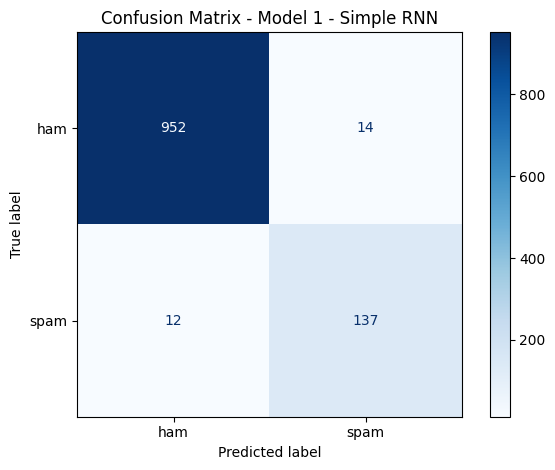

In [79]:
y_pred_rnn, probs_rnn = evaluate_model(
    rnn_model,
    X_test_pad,
    y_test,
    'Model 1 - Simple RNN'
)

Model 2 - LSTM (Trainable)

Test Accuracy: 0.9848

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



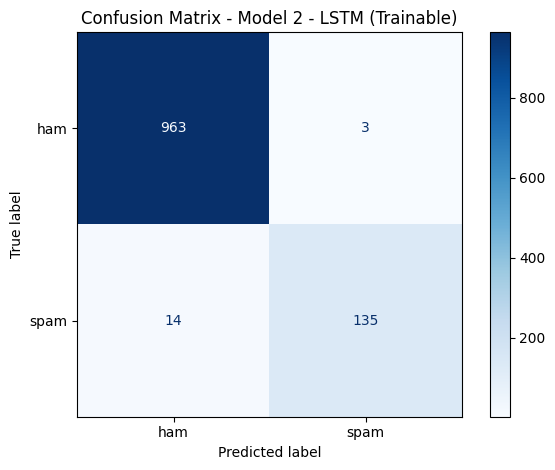

In [80]:
y_pred_lstm, probs_lstm = evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
    'Model 2 - LSTM (Trainable)'
)

Model 3 - LSTM (GloVe)

Test Accuracy: 0.9534

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      0.99      0.97       966
        spam       0.90      0.73      0.81       149

    accuracy                           0.95      1115
   macro avg       0.93      0.86      0.89      1115
weighted avg       0.95      0.95      0.95      1115



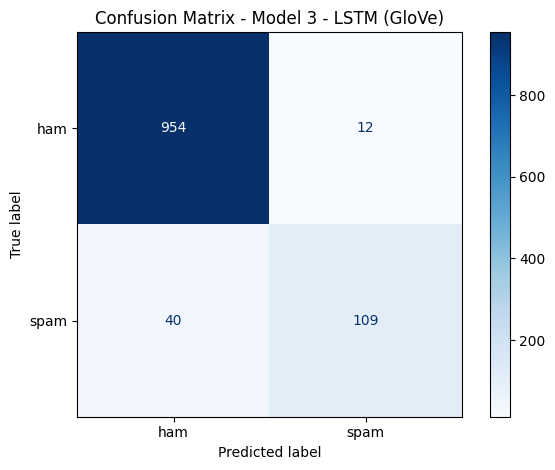

In [81]:
y_pred_glove, probs_glove = evaluate_model(
    lstm_w2v_model,
    X_test_pad,
    y_test,
    'Model 3 - LSTM (GloVe)'
)

# Error Analysis

### Misclassified Examples

In [82]:
# Build a results dataframe for the test set
df_test = pd.DataFrame({
    'cleaned_message': X_test,
    'true_label'     : y_test,
    'pred_rnn'       : y_pred_rnn,
    'pred_lstm'      : y_pred_lstm,
    'pred_w2v'       : y_pred_glove,
    'prob_lstm'      : probs_lstm
})

# Misclassifications according to Model 2 (LSTM)
misclassified = df_test[
    df_test['true_label'] != df_test['pred_lstm']
].reset_index(drop=True)

fp = ((misclassified['true_label'] == 0) & (misclassified['pred_lstm'] == 1)).sum()
fn = ((misclassified['true_label'] == 1) & (misclassified['pred_lstm'] == 0)).sum()

print(f"Total misclassified by LSTM (Model 2) : {len(misclassified)}")
print(f"  False Positives - Ham predicted as Spam : {fp}")
print(f"  False Negatives - Spam predicted as Ham : {fn}")

Total misclassified by LSTM (Model 2) : 17
  False Positives - Ham predicted as Spam : 3
  False Negatives - Spam predicted as Ham : 14


In [83]:
label_map = {0: 'Ham', 1: 'Spam'}

print("  SAMPLE MISCLASSIFIED EXAMPLES - LSTM (Model 2)")

for i, row in misclassified.head(3).iterrows():
    print(f"\n  Example {i + 1}")
    print(f"  Cleaned text         : {row['cleaned_message']}")
    print(f"  True label           : {label_map[int(row['true_label'])]}")
    print(f"  LSTM prediction      : {label_map[int(row['pred_lstm'])]}  "
          f"(spam prob: {row['prob_lstm']:.3f})")
    print(f"  RNN  prediction      : {label_map[int(row['pred_rnn'])]}")
    print(f"  GloVe prediction     : {label_map[int(row['pred_w2v'])]}")

  SAMPLE MISCLASSIFIED EXAMPLES - LSTM (Model 2)

  Example 1
  Cleaned text         : adult would learn experience real danger dont like peep using drug dont need comment
  True label           : Ham
  LSTM prediction      : Spam  (spam prob: 0.584)
  RNN  prediction      : Spam
  GloVe prediction     : Ham

  Example 2
  Cleaned text         : ringtoneking
  True label           : Spam
  LSTM prediction      : Ham  (spam prob: 0.003)
  RNN  prediction      : Ham
  GloVe prediction     : Ham

  Example 3
  Cleaned text         : sorry missed call let u talk time
  True label           : Spam
  LSTM prediction      : Ham  (spam prob: 0.003)
  RNN  prediction      : Ham
  GloVe prediction     : Ham


### Model Complexity vs Performance

In [84]:
summary_data = {
    'Model': [
        'Model 1 - Simple RNN',
        'Model 2 - LSTM (Trainable)',
        'Model 3 - LSTM (GloVe)'
    ],

    'Params': [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_w2v_model.count_params()
    ],

    'Test Accuracy': [
        test_accuracies['Model 1\nSimple RNN'],
        test_accuracies['Model 2\nLSTM (Trainable)'],
        test_accuracies['Model 3\nLSTM (GloVe)']
    ],

    'Recurrent Unit': [
        'SimpleRNN',
        'LSTM',
        'LSTM'
    ],

    'Embedding': [
        'Trainable',
        'Trainable',
        'Frozen GloVe'
    ]
}

summary_df = pd.DataFrame(summary_data)

summary_df['Test Accuracy (raw)'] = summary_df['Test Accuracy']
summary_df['Test Accuracy'] = summary_df['Test Accuracy'].map('{:.4f}'.format)
print('\nModel Complexity vs Performance:')
display(summary_df)


Model Complexity vs Performance:


,Model,Params,Test Accuracy,Recurrent Unit,Embedding,Test Accuracy (raw)
0,Model 1 - Simple RNN,650369,97.6682,SimpleRNN,Trainable,97.668159
1,Model 2 - LSTM (Trainable),675137,98.4753,LSTM,Trainable,98.475337
2,Model 3 - LSTM (GloVe),531553,95.3363,LSTM,Frozen GloVe,95.336324


# GUI for Real Time Prediction

In [85]:
def predict_spam(message: str) -> str:
    """Preprocess input and return predictions from all models."""

    if not message.strip():
        return "Please enter a message."

    # preprocessing
    cleaned = clean_text(message)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # predictions
    p1 = rnn_model.predict(padded, verbose=0)[0][0]
    p2 = lstm_model.predict(padded, verbose=0)[0][0]
    p3 = lstm_w2v_model.predict(padded, verbose=0)[0][0]

    def fmt(prob: float) -> str:
        label = "SPAM" if prob >= 0.5 else "HAM"
        bar = '█' * int(prob * 20) + '░' * (20 - int(prob * 20))
        return f"{label} | [{bar}] | {prob*100:.1f}% spam probability"

    return (
        f"Cleaned text:\n{cleaned}\n\n"
        f"----------------------------------------\n"
        f"Model 1 (Simple RNN): {fmt(p1)}\n"
        f"Model 2 (LSTM): {fmt(p2)}\n"
        f"Model 3 (LSTM + GloVe): {fmt(p3)}\n"
    )


examples = [
    ["WINNER!! You've been selected to receive a £900 prize. Call NOW!"],
    ["Hey, are you coming to the party tonight?"],
    ["Congratulations! Your mobile number has won a FREE holiday. Claim now."],
    ["Can you pick up some milk on your way home please?"],
    ["FREE entry to our exclusive prize draw! Text WIN to 80082 NOW!"],
]


demo = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type or paste an SMS message here...",
        label="Input Message"
    ),
    outputs=gr.Textbox(
        label="Prediction Results",
        lines=8
    ),
    title="SMS Spam Detection Model",
    description=(
        "Enter an SMS message. The system preprocesses it and predicts spam probability "
        "using three models: Simple RNN, LSTM, and LSTM + GloVe."
    ),
    examples=examples,
    theme=gr.themes.Soft(primary_hue="fuchsia")
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f94b7820544f0cb93.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
